In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
from sklearn import svm
from sklearn.svm import SVC
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import os
import pandas as pd
import joblib
from homeharvest import scrape_property
import matplotlib.pyplot as plt
data = pd.read_csv("HousingData.csv")
for dirname, _, filenames in os.walk("./"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

./housing_price_model.joblib
./Project_2.ipynb
./HousingData.csv
./.ipynb_checkpoints/HousingData-checkpoint.csv
./.ipynb_checkpoints/Project_2-checkpoint.ipynb


# 1. Frame the problem
Using the customer description, Define the problem your trying to solve in your own words (remember this is not technial but must be specific so the customer understands the project

Using Machine Learning write a program to predict housing prices in an American City. 
The dataset must be gathered on your own and must contain at least a 1000 rows of data.

# 2. Get the Data 
Define how you recieved the data (provided, gathered..)

I used the homeharvest library to scrape the housing data for Miami,FL from zillow

In [ ]:
# filename = "HousingData.csv"
# properties = scrape_property(
#   location="Miami, FL",
#   listing_type="sold",
#   past_days=180,
# )
# print(f"Number of properties: {len(properties)}")

# properties.to_csv(filename, index=False)

# 3. Explore the Data
Gain insights into the data you have from step 2, making sure to identify any bias

The data contains many columns that can be used for this project. I have identified the ones that are potentially benficial 
beds, full_baths, half_baths, sqft, lot_sqft, year_built, stories, style, new_construction, parking_garage, zip_code
latitude, longitude, neighborhoods, list_price, sold_price, last_sold_price, assessed_value, estimated_value, price_per_sqft, tax, days_on_mls, 
list_date, last_sold_date. These could be used to classify the homes into areas which for the city of Miami would have a significant effect on the price. In terms of bias I have not found any other than the missing data which could potentially skew the results. 

/tmp/ipykernel_3569893/5459117.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  squarefoot_price = data.groupby(pd.cut(data['sqft'], bins=[1000,2000,3000,4000,5000,6000,7000,8000,9000,10000]))['list_price'].mean()


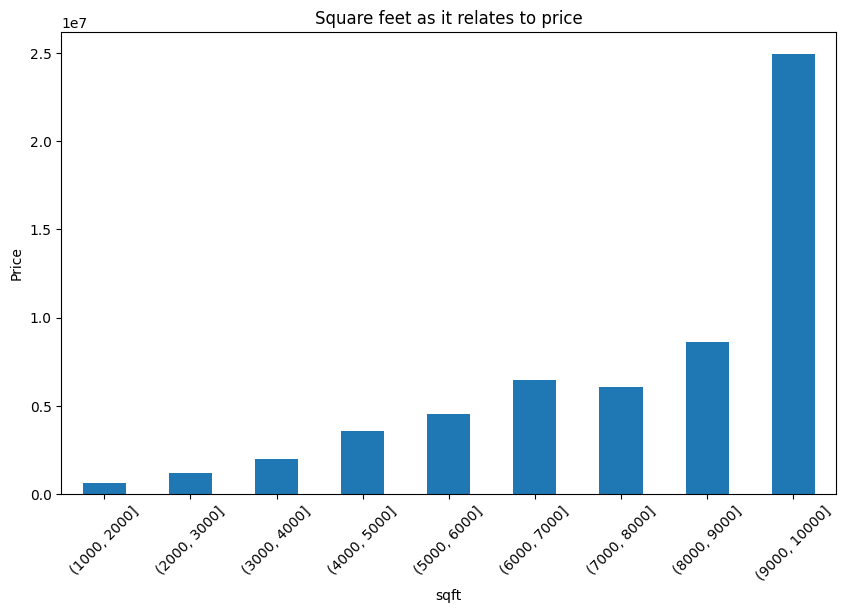

In [4]:
squarefoot_price = data.groupby(pd.cut(data['sqft'], bins=[1000,2000,3000,4000,5000,6000,7000,8000,9000,10000]))['list_price'].mean()
fig, ax = plt.subplots(figsize=(10, 6))
squarefoot_price.plot(kind='bar', ax=ax)
ax.set_title('Square feet as it relates to price')
ax.set_ylabel('Price')
plt.xticks(rotation=45)
plt.show()

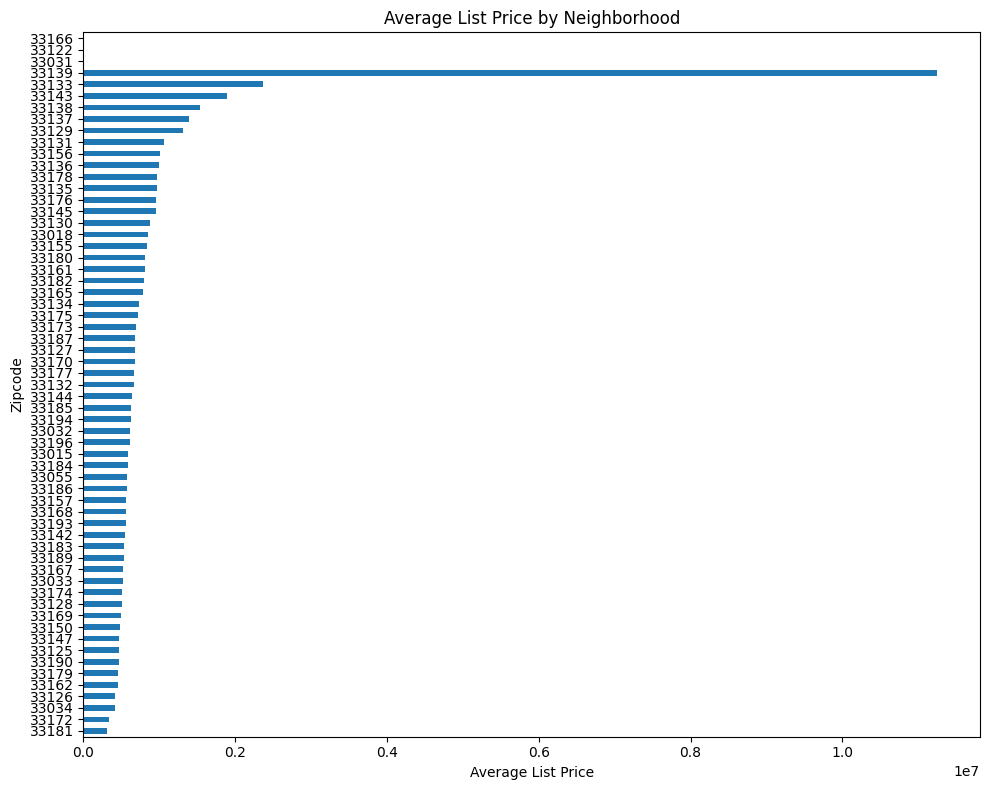

In [5]:
average_prices = data.groupby('zip_code')['list_price'].mean()
average_prices.sort_values().plot(kind='barh', figsize=(10, 8))
plt.xlabel('Average List Price')
plt.ylabel('Zipcode')
plt.title('Average List Price by Neighborhood')
plt.tight_layout()
plt.show()

# 4.Prepare the Data


Apply any data transformations and explain what and why


For the data transformations is dropped the Null data slots and thats all I did. 

# 5. Model the data
Using selected ML models, experment with your choices and describe your findings. Finish by selecting a Model to continue with


I tried to use SVM but it was getting me 65% at the most but after I switched to random forest I got around a 71% accuracy. 

In [72]:
y = data["sold_price"]
features = ["zip_code" ,"beds", "full_baths", "half_baths", "sqft", "lot_sqft","neighborhoods","stories"]
x = pd.get_dummies(data[features])
x = x.dropna()
y = y.loc[x.index]
X_train, X_valid, Y_train, Y_valid = train_test_split(
    x, y, train_size=0.8, test_size=0.2, random_state=50)
model_SVR = svm.SVR()
model_SVR.fit(X_train,Y_train)
Y_pred = model_SVR.predict(X_valid)
mape = mean_absolute_percentage_error(Y_valid, Y_pred)
accuracy = 1-mape
print(f"Model Accuracy: {accuracy*100:.3f}%")

Model Accuracy: 65.284%


# 6. Fine Tune the Model

With the select model descibe the steps taken to acheve the best rusults possiable 


I added more parameters into my random forest model so that it would be able to predict more accurate. Once I set random_state to 4 i got a 10% accuracy increase bringing my total to 81.37%

In [27]:
y = data["sold_price"]
features = ["zip_code", "beds", "full_baths", "half_baths", "sqft", "lot_sqft", "neighborhoods", "stories"]
X = pd.get_dummies(data[features])
X = X.dropna()
y = y.loc[X.index]
X_train, X_valid, Y_train, Y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=4)
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=4,
    n_jobs=-1
)
model.fit(X_train, Y_train)
Y_pred = model.predict(X_valid)
mape = mean_absolute_percentage_error(Y_valid, Y_pred)
accuracy = 1 - mape
print(f"Random Forest Accuracy: {accuracy*100:.3f}%")
joblib.dump((model, X.columns), "housing_price_model.joblib")
test_house = pd.DataFrame({
    "zip_code": [33176],
    "beds": [3.0],
    "full_baths": [2.0],
    "half_baths": [1.0],
    "sqft": [3525],
    "lot_sqft": [0],   
    "neighborhoods": ["Brickell"],
    "stories": [1.0]})
loaded_model, train_columns = joblib.load("housing_price_model.joblib")
test_house_enc = pd.get_dummies(test_house)
test_house_enc = test_house_enc.reindex(columns=train_columns, fill_value=0)
predicted_price = loaded_model.predict(test_house_enc)
print(f"Predicted Price for the New House: ${predicted_price[0]:,.2f}")

Random Forest Accuracy: 81.370%
Predicted Price for the New House: $1,325,819.33


# 7. Present
In a customer faceing Document provide summery of finding and detail approach taken


# 8. Launch the Model System
Define your production run code, This should be self susficent and require only your model pramaters 


In [ ]:
def infrence(prams):
    results = m.run(prams)
    return results 